In [2]:
import pandas as pd
import numpy as np


In [3]:
feature_df = pd.read_csv(
    "../data/processed/application_train_feature_engineered.csv"
)

In [4]:
# ======================================================
# Section 1: Separate Features and Target
# ======================================================

# Independent Features
X = feature_df.drop(columns=["TARGET"])

# Target Variable
y = feature_df["TARGET"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

Feature Matrix Shape : (307511, 248)
Target Vector Shape  : (307511,)

Target Distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [5]:
# ======================================================
# Section 2: Train-Test Split
# ======================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (246008, 248)
X_test Shape  : (61503, 248)
y_train Shape : (246008,)
y_test Shape  : (61503,)


In [6]:
# ======================================================
# Section 3: Handle Class Imbalance
# ======================================================

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print(f"Negative Samples : {negative}")
print(f"Positive Samples : {positive}")
print(f"Scale Pos Weight : {scale_pos_weight:.2f}")

Negative Samples : 226148
Positive Samples : 19860
Scale Pos Weight : 11.39


In [7]:
# ======================================================
# Section 4: Train XGBoost Model
# ======================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("✅ XGBoost Model Trained Successfully!")

✅ XGBoost Model Trained Successfully!


In [8]:
# ======================================================
# Section 5: Make Predictions
# ======================================================

# Predict class labels
y_pred = xgb_model.predict(X_test)

# Predict probabilities for the positive class (TARGET = 1)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print("✅ Predictions Generated Successfully!")

print("\nFirst 10 Predicted Classes:")
print(y_pred[:10])

print("\nFirst 10 Prediction Probabilities:")
print(y_prob[:10])

✅ Predictions Generated Successfully!

First 10 Predicted Classes:
[0 0 1 0 1 0 0 0 1 0]

First 10 Prediction Probabilities:
[0.352571   0.37733993 0.7856472  0.35700974 0.52630895 0.4948124
 0.09923897 0.08345445 0.8778602  0.4778605 ]


In [9]:
# ======================================================
# Section 6: Model Evaluation
# ======================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 45)
print("XGBoost Model Performance")
print("=" * 45)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

XGBoost Model Performance
Accuracy : 0.7350
Precision: 0.1824
Recall   : 0.6558
F1 Score : 0.2855
ROC-AUC  : 0.7683


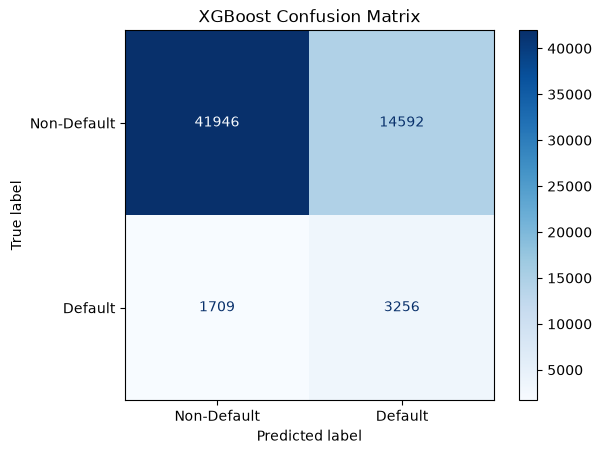

In [10]:
# ======================================================
# Section 7: Confusion Matrix
# ======================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Default", "Default"]
)

disp.plot(cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [11]:
# ======================================================
# Section 8: Classification Report
# ======================================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.74      0.84     56538
           1       0.18      0.66      0.29      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.70      0.56     61503
weighted avg       0.90      0.73      0.79     61503



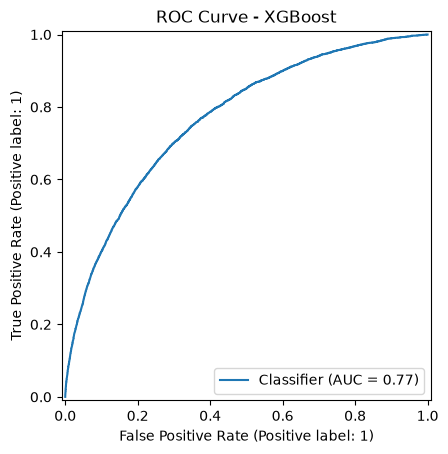

In [12]:
# ======================================================
# Section 9: ROC Curve
# ======================================================

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - XGBoost")
plt.show()

<Figure size 1000x1200 with 0 Axes>

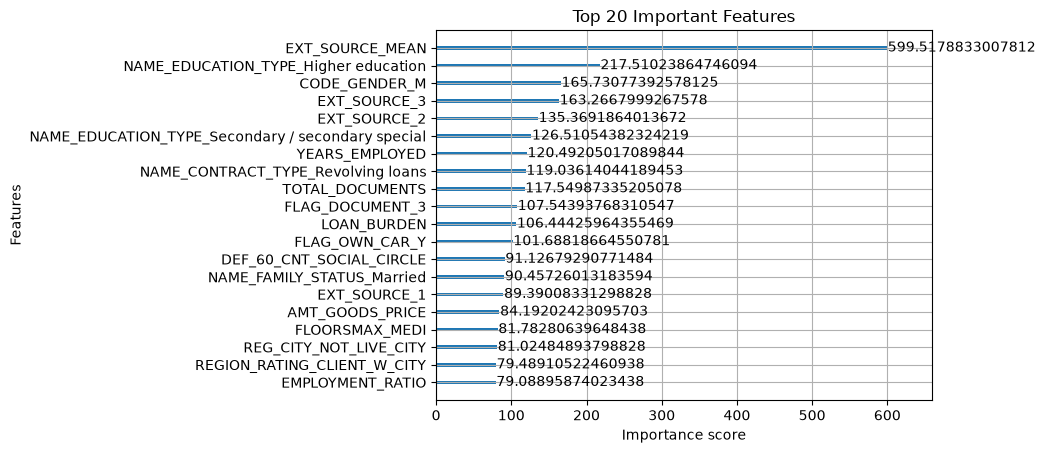

In [13]:
# ======================================================
# Section 10: Feature Importance
# ======================================================

from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 12))

plot_importance(
    xgb_model,
    max_num_features=20,
    importance_type="gain"
)

plt.title("Top 20 Important Features")
plt.show()

## Hyperparameter tuning using RandomizedSreachCV

In [16]:
# ======================================================
# Section 14: Hyperparameter Tuning
# ======================================================

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

# Base XGBoost Model
xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

# Hyperparameter Search Space
param_grid = {

    "n_estimators": [200, 300, 400, 500],

    "max_depth": [3, 4, 5, 6, 7, 8],

    "learning_rate": [0.01, 0.03, 0.05, 0.1],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "min_child_weight": [1, 3, 5],

    "gamma": [0, 0.1, 0.3, 0.5]
}

# Randomized Search
random_search = RandomizedSearchCV(

    estimator=xgb_base,

    param_distributions=param_grid,

    n_iter=5,

    scoring="roc_auc",

    cv=3,

    verbose=2,

    random_state=42,

    n_jobs=-1

)

print("Hyperparameter Tuning Started...\n")

# Train
random_search.fit(X_train, y_train)

print("\nHyperparameter Tuning Completed!")

Hyperparameter Tuning Started...

Fitting 3 folds for each of 5 candidates, totalling 15 fits


d:\Credit-Risk-Prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
3 fits failed out of a total of 15.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Credit-Risk-Prediction\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Credit-Risk-Prediction\.venv\Lib\site-packages\xgboost\core.py", line 553, in inner_f
    return func(**kwargs)
  File "d:\Credit-Risk-Prediction\.venv\Lib\site-packages\xgboost\sklearn.py", line 1788, in fit
    train_dmatrix, evals = _


Hyperparameter Tuning Completed!


In [17]:

# Section 15: Best Hyperparameters


print("=" * 60)
print("Best Hyperparameters")
print("=" * 60)

print(random_search.best_params_)

print("\nBest Cross Validation ROC-AUC")

print(round(random_search.best_score_,4))

Best Hyperparameters
{'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}

Best Cross Validation ROC-AUC
0.7523


In [18]:

# Section 16: Best Model


best_xgb_model = random_search.best_estimator_

print(best_xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


In [19]:
# Section 17: Predictions


y_pred_tuned = best_xgb_model.predict(X_test)

y_prob_tuned = best_xgb_model.predict_proba(X_test)[:,1]

In [20]:
# ======================================================
# Section 18: Evaluation
# ======================================================

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

accuracy = accuracy_score(y_test,y_pred_tuned)

precision = precision_score(y_test,y_pred_tuned)

recall = recall_score(y_test,y_pred_tuned)

f1 = f1_score(y_test,y_pred_tuned)

roc_auc = roc_auc_score(y_test,y_prob_tuned)

print("="*50)

print("Tuned XGBoost Performance")

print("="*50)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC AUC  : {roc_auc:.4f}")

Tuned XGBoost Performance
Accuracy : 0.7567
Precision: 0.1885
Recall   : 0.6095
F1 Score : 0.2880
ROC AUC  : 0.7617


In [21]:
# ======================================================
# Section 19: Model Comparison
# ======================================================

comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Baseline":[
        0.7350,
        0.1824,
        0.6558,
        0.2855,
        0.7683
    ],

    "Tuned":[
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

})

comparison

,Metric,Baseline,Tuned
0,Accuracy,0.7350,0.756727
1,Precision,0.1824,0.188548
2,Recall,0.6558,0.609466
3,F1 Score,0.2855,0.287998
4,ROC-AUC,0.7683,0.761720


In [22]:
# ======================================================
# Section 20: Save Best Model
# ======================================================

import joblib
from pathlib import Path

model_path = Path("../models")

model_path.mkdir(parents=True,exist_ok=True)

joblib.dump(
    best_xgb_model,
    model_path/"xgboost_model.pkl"
)

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


In [23]:
import joblib
from pathlib import Path

model_path = Path("../models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(
    xgb_model,
    model_path / "xgboost_baseline.pkl"
)

print("✅ Baseline XGBoost model saved successfully!")

✅ Baseline XGBoost model saved successfully!


In [24]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    model_path / "feature_names.pkl"
)

print("✅ Feature Names Saved!")

✅ Feature Names Saved!


In [25]:
results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

results

,Metric,Score
0,Accuracy,0.756727
1,Precision,0.188548
2,Recall,0.609466
3,F1 Score,0.287998
4,ROC-AUC,0.761720


In [26]:
results.to_csv(
    "../models/xgboost_results.csv",
    index=False
)

print("✅ Performance Report Saved!")

✅ Performance Report Saved!
